<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""Program 14: Dataset: <Wine_Quality.csv>
a) Conduct exploratory data analysis on the given dataset and report
the details.
b) Visualize the analysis results using (i) histogram and (ii) box plot.
c) Implement the Naïve Bayes classification algorithm using the
dataset. Display the classification report with the accuracy."""
# a) Conduct Exploratory Data Analysis (EDA)
import pandas as pd
df = pd.read_csv('/content/WineQT.csv') # Load the Wine Quality dataset
print(df.head()) # Check the first few rows
print(df.isnull().sum()) # Check for missing values
print(df.describe()) # Summary statistics of the dataset
print(df['quality'].value_counts()) # Distribution of the target variable 'quality'



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

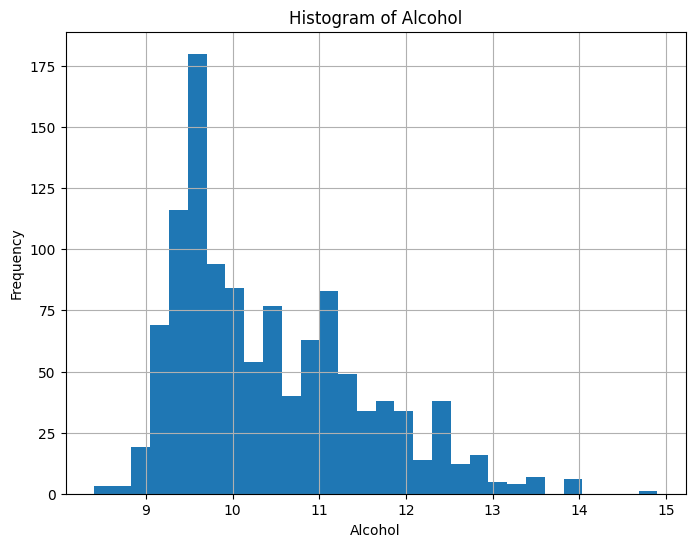

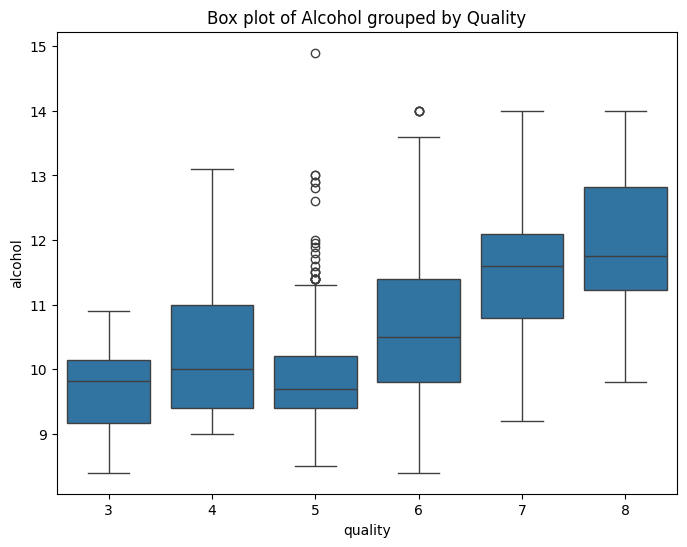

In [2]:
#b) Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
# (i) Histogram for a feature like 'alcohol'
plt.figure(figsize=(8, 6))
df['alcohol'].hist(bins=30)
plt.title("Histogram of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()
# (ii) Box plot for 'alcohol' grouped by 'quality'
plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Box plot of Alcohol grouped by Quality")
plt.show()

In [4]:
#c) Implement Naïve Bayes Classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer # import the imputer
# Step 1: Convert 'quality' into binary class (e.g., good quality = 1 if quality >= 7, otherwise bad quality = 0)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
# Step 2: Prepare features (X) and target (y)
# drop 'type', 'quality', and the newly created 'quality_label' for the features
X = df.drop(columns=['quality', 'quality_label', 'Id'])
y = df['quality_label']
# Step 3: Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Step 4: Impute missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean') # create an imputer object with strategy 'mean'
X_train = imputer.fit_transform(X_train) # fit and transform on the training data
X_test = imputer.transform(X_test) # transform the test data
# Step 5: Train the Naive Bayes classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
# Step 6: Make predictions on the test set
y_pred = nb_model.predict(X_test)
# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
# Output the results
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n", classification_rep)

Accuracy: 83.84%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.85      0.90       201
           1       0.41      0.75      0.53        28

    accuracy                           0.84       229
   macro avg       0.69      0.80      0.72       229
weighted avg       0.89      0.84      0.86       229

